In [1]:
!pip install pennylane imbalanced-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time, os, pickle
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import pennylane as qml
from pennylane import numpy as pnp

print("Imports done. PennyLane:", qml.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 94.5 MB/s eta 0:00:00
Imports done. PennyLane: 0.45.0


In [2]:
# Load dataset
csv_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for f in filenames:
        if 'PS_' in f and f.endswith('.csv'):
            csv_path = os.path.join(dirname, f)

print("Found:", csv_path)
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("Fraud %:", round(df['isFraud'].mean() * 100, 4))

# Encode transaction type
le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])

# Select features relevant to fraud
FEATURES = ['type_enc', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest']

# Derived features
df['balance_diff_orig'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']
FEATURES += ['balance_diff_orig', 'balance_diff_dest']

X = df[FEATURES].values
y = df['isFraud'].values
feature_names = FEATURES

print("Features:", feature_names)
print("Class dist:", np.bincount(y))

# Scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Balance with RUS
rus = RandomUnderSampler(random_state=42)
X_train, y_train = rus.fit_resample(X_train_raw, y_train_raw)
X_test,  y_test  = rus.fit_resample(X_test_raw,  y_test_raw)

print("Train:", X_train.shape, np.bincount(y_train))
print("Test: ", X_test.shape,  np.bincount(y_test))

Found: /kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv
Shape: (6362620, 11)
Fraud %: 0.1291
Features: ['type_enc', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_diff_orig', 'balance_diff_dest']
Class dist: [6354407    8213]
Train: (13140, 8) [6570 6570]
Test:  (3286, 8) [1643 1643]


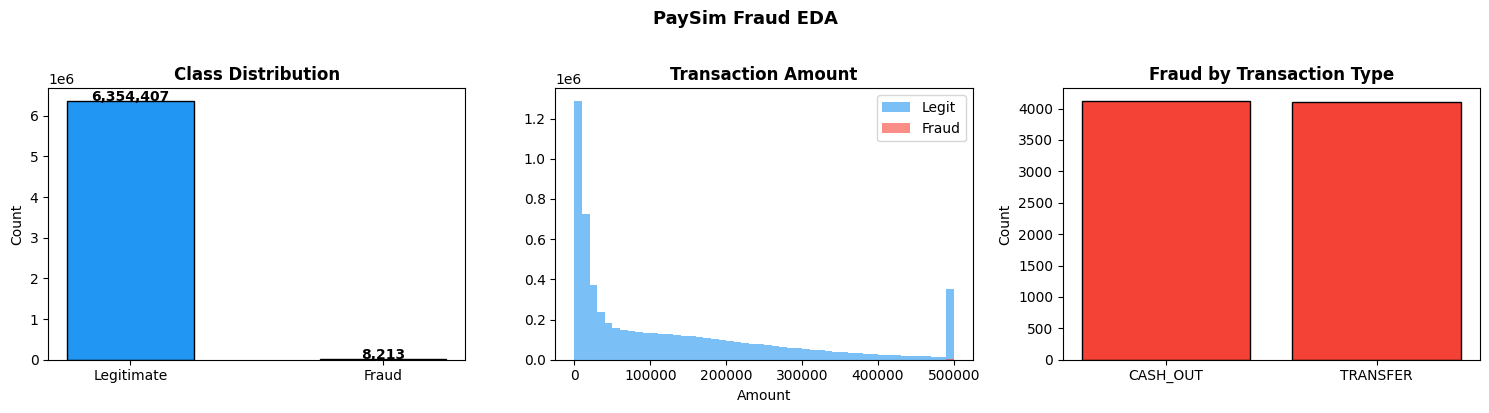

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class balance
counts = pd.Series(y).value_counts()
axes[0].bar(['Legitimate', 'Fraud'], [counts[0], counts[1]],
            color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Amount distribution
axes[1].hist(df[df['isFraud']==0]['amount'].clip(upper=500000),
             bins=50, alpha=0.6, color='#2196F3', label='Legit')
axes[1].hist(df[df['isFraud']==1]['amount'].clip(upper=500000),
             bins=50, alpha=0.6, color='#F44336', label='Fraud')
axes[1].set_title('Transaction Amount', fontweight='bold')
axes[1].set_xlabel('Amount'); axes[1].legend()

# Transaction type for fraud
fraud_types = df[df['isFraud']==1]['type'].value_counts()
axes[2].bar(fraud_types.index, fraud_types.values,
            color='#F44336', edgecolor='black')
axes[2].set_title('Fraud by Transaction Type', fontweight='bold')
axes[2].set_ylabel('Count')

plt.suptitle('PaySim Fraud EDA', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [4]:
N_QUBITS = 3
N_LAYERS = 1

q_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_angle = q_scaler.fit_transform(X_train)[:, :N_QUBITS]
X_test_angle  = q_scaler.transform(X_test)[:, :N_QUBITS]

VQC_TRAIN, VQC_TEST = 200, 60
idx_tr = np.concatenate([np.where(y_train==0)[0][:VQC_TRAIN//2],
                          np.where(y_train==1)[0][:VQC_TRAIN//2]])
idx_te = np.concatenate([np.where(y_test==0)[0][:VQC_TEST//2],
                          np.where(y_test==1)[0][:VQC_TEST//2]])

X_vqc_tr, y_vqc_tr = X_train_angle[idx_tr], y_train[idx_tr]
X_vqc_te, y_vqc_te = X_test_angle[idx_te],  y_test[idx_te]
y_vqc_pm = np.where(y_vqc_tr == 1, 1.0, -1.0)

dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev)
def vqc_circuit(weights, x):
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)
    for i in range(N_QUBITS):
        qml.RY(weights[i, 0], wires=i)
        qml.RZ(weights[i, 1], wires=i)
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i+1])
    return qml.expval(qml.PauliZ(0))

np.random.seed(42)
weights = pnp.array(
    np.random.uniform(-np.pi, np.pi, (N_QUBITS, 2)),
    requires_grad=True
)
opt = qml.AdamOptimizer(stepsize=0.05)
EPOCHS, BATCH_SIZE = 10, 25
loss_history = []

print("Training VQC...")
t0 = time.time()
for epoch in range(EPOCHS):
    perm = np.random.permutation(len(X_vqc_tr))
    X_sh, y_sh = X_vqc_tr[perm], y_vqc_pm[perm]
    epoch_loss, n_b = 0.0, 0
    for start in range(0, len(X_sh), BATCH_SIZE):
        Xb, yb = X_sh[start:start+BATCH_SIZE], y_sh[start:start+BATCH_SIZE]
        def cost_fn(w):
            preds = pnp.array([vqc_circuit(w, x) for x in Xb])
            return pnp.mean((preds - yb) ** 2)
        weights, loss_val = opt.step_and_cost(cost_fn, weights)
        epoch_loss += float(loss_val); n_b += 1
    avg = epoch_loss / n_b
    loss_history.append(avg)
    print(f"  Epoch {epoch+1}/{EPOCHS}  loss={avg:.4f}  ({round(time.time()-t0,1)}s)")

print(f"Done in {round(time.time()-t0,1)}s")

Training VQC...
  Epoch 1/10  loss=1.7688  (2.0s)
  Epoch 2/10  loss=1.5419  (4.2s)
  Epoch 3/10  loss=1.3561  (6.4s)
  Epoch 4/10  loss=1.2774  (8.5s)
  Epoch 5/10  loss=1.2490  (10.6s)
  Epoch 6/10  loss=1.2593  (12.9s)
  Epoch 7/10  loss=1.2598  (15.0s)
  Epoch 8/10  loss=1.2481  (17.1s)
  Epoch 9/10  loss=1.2500  (19.4s)
  Epoch 10/10  loss=1.2482  (21.5s)
Done in 21.5s


              precision    recall  f1-score   support

       Legit       1.00      0.07      0.12        30
       Fraud       0.52      1.00      0.68        30

    accuracy                           0.53        60
   macro avg       0.76      0.53      0.40        60
weighted avg       0.76      0.53      0.40        60

ROC-AUC: 0.4739


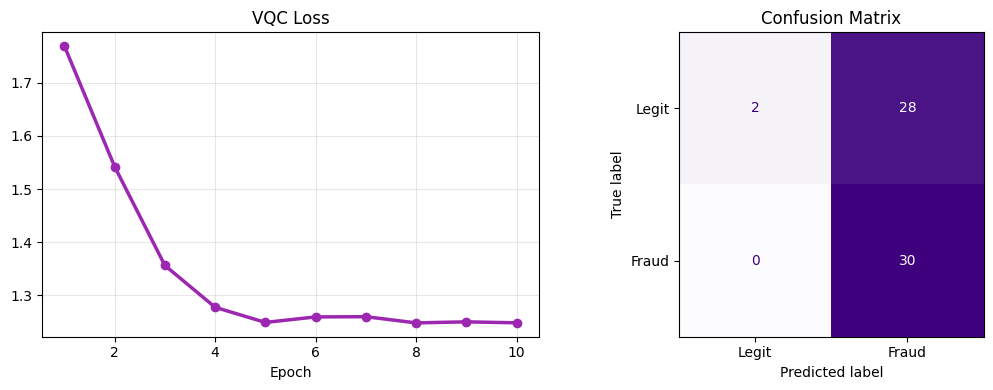

In [5]:
raw_scores  = np.array([float(vqc_circuit(weights, x)) for x in X_vqc_te])
y_proba_vqc = (raw_scores + 1) / 2
y_pred_vqc  = (y_proba_vqc >= 0.5).astype(int)

print(classification_report(y_vqc_te, y_pred_vqc, target_names=['Legit','Fraud']))
print("ROC-AUC:", round(roc_auc_score(y_vqc_te, y_proba_vqc), 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, EPOCHS+1), loss_history, color='#9C27B0', linewidth=2.5, marker='o')
axes[0].set_title('VQC Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)

ConfusionMatrixDisplay(
    confusion_matrix(y_vqc_te, y_pred_vqc),
    display_labels=['Legit','Fraud']
).plot(ax=axes[1], colorbar=False, cmap='Purples')
axes[1].set_title('Confusion Matrix')
plt.tight_layout(); plt.show()

In [6]:
_dev_save = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(_dev_save)
def _vqc_global(weights, x):
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)
    for i in range(N_QUBITS):
        qml.RY(weights[i, 0], wires=i)
        qml.RZ(weights[i, 1], wires=i)
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i+1])
    return qml.expval(qml.PauliZ(0))

class VQCFraudDetector:
    def __init__(self, scaler, q_scaler, weights, n_qubits, threshold=0.5):
        self.scaler = scaler; self.q_scaler = q_scaler
        self.weights = weights; self.n_qubits = n_qubits
        self.threshold = threshold

    def predict_single(self, x_raw):
        x = self.q_scaler.transform(self.scaler.transform(
            np.array(x_raw).reshape(1,-1).astype(float)))[:, :self.n_qubits]
        prob = (float(_vqc_global(self.weights, x[0])) + 1) / 2
        pred = int(prob >= self.threshold)
        return {'label': 'FRAUD' if pred else 'LEGITIMATE', 'score': round(prob,4)}

detector = VQCFraudDetector(scaler, q_scaler, weights, N_QUBITS)

SAVE_PATH = '/kaggle/working/vqc_paysim.pkl'
with open(SAVE_PATH, 'wb') as f:
    pickle.dump(detector, f)
print(f"Saved! ({os.path.getsize(SAVE_PATH)/1024:.1f} KB)")

with open(SAVE_PATH, 'rb') as f:
    loaded = pickle.load(f)
print(loaded.predict_single(X_test[0]))
print("True:", 'FRAUD' if y_test[0] else 'LEGITIMATE')

Saved! (1.5 KB)
{'label': 'LEGITIMATE', 'score': 0.3103}
True: LEGITIMATE
